In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def load_csv(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    # ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1

def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, np.abs(Y / len(y))

def get_peak_freq(t, y):
    mask = t > 0
    f, Y = compute_fft(t[mask], y[mask])
    Y = np.abs(Y)
    fig, ax = plt.subplots()
    ax.plot(f, Y)
    return np.abs(f[np.argmax(Y)]) / 1e6

(-2.5e-06, 2.5e-06)

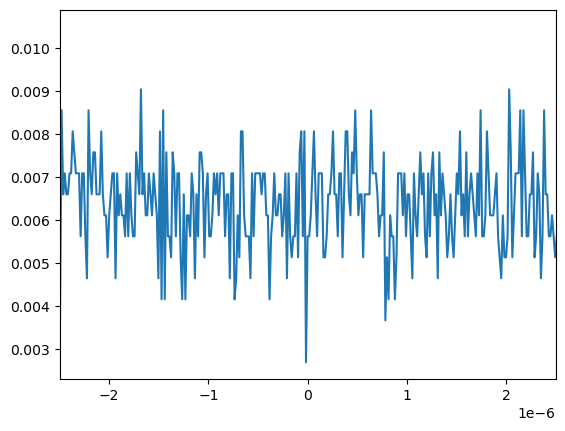

In [15]:
t, ch1 = load_csv("D:/data/WFM01.CSV")
fig, ax = plt.subplots()
ax.plot(t, ch1)
ax.set_xlim([-0.25e-5, 0.25e-5])

# f, Y = compute_fft(t, ch1)
# fig, ax = plt.subplots()
# ax.plot(f, Y)
# print(get_peak_freq(t, ch1))

16.928386322265624


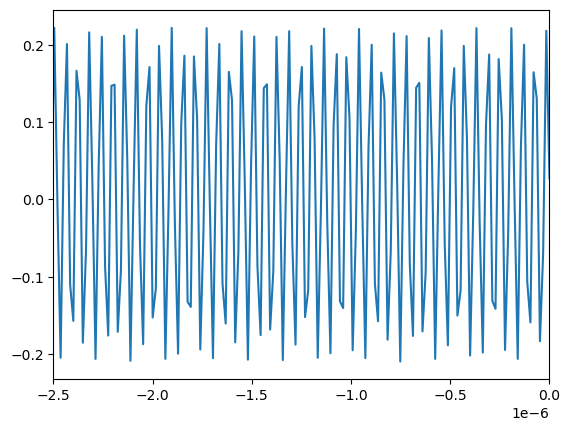

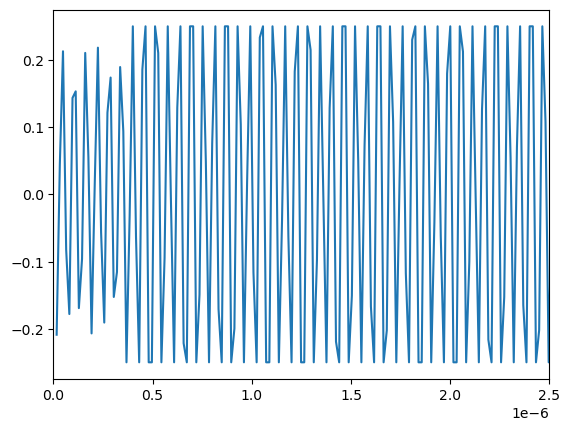

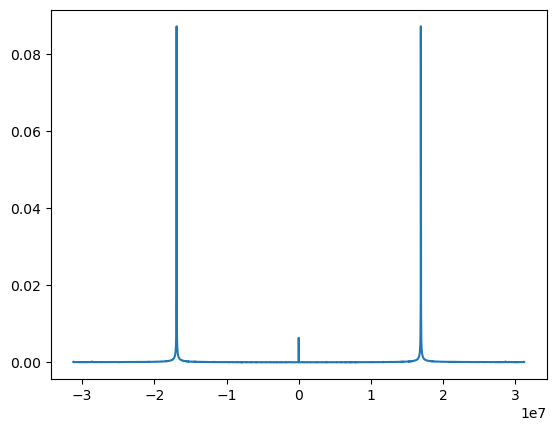

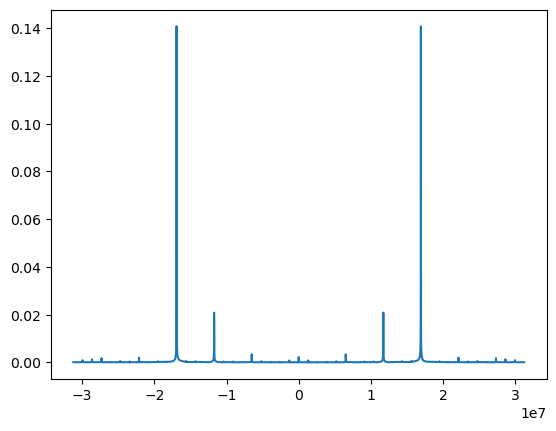

In [ ]:
t, ch1 = load_csv("D:/data/WFM08.CSV")
fig, ax = plt.subplots()
ax.plot(t[t<0], ch1[t<0])
ax.set_xlim([-0.25e-5, 0])

fig, ax = plt.subplots()
ax.plot(t[t>0], ch1[t>0])
ax.set_xlim([0, 0.25e-5])

f, Y = compute_fft(t[t<0], ch1[t<0])
fig, ax = plt.subplots()
ax.plot(f, Y)
print(get_peak_freq(t, ch1))

# [ 5.373296 38.923847 33.074005 22.505043 22.217746 43.071298  5.211336
#  35.171034 10.872007  5.61469 ]